In [139]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [140]:
df = pd.read_csv("data/processed/DELHI_MASTER_AQI_WEATHER_2025.csv")

df["datetime"] = pd.to_datetime(df["datetime"])

print(df.shape)
df.head()

(144648, 27)


,datetime,date,year,month,day,hour,day_of_week,is_weekend,station,latitude,...,rain_mm,wind_speed_ms,wind_dir_deg,wind_gust_ms,solar_ghi_wm2,solar_direct_wm2,solar_diffuse_wm2,cloud_cover_pct,visibility_m,vpd_kpa
0,2025-01-01,2025-01-01,2025,1,1,0,2,0,Alipur,28.798600,...,0.0,0.79,305,1.8,0.0,0.0,0.0,98,NaN,0.0
1,2025-01-01,2025-01-01,2025,1,1,0,2,0,Bawana,28.623000,...,0.0,0.51,281,0.9,0.0,0.0,0.0,100,NaN,0.0
2,2025-01-01,2025-01-01,2025,1,1,0,2,0,Burari,28.716700,...,0.0,0.79,288,2.0,0.0,0.0,0.0,100,NaN,0.0
3,2025-01-01,2025-01-01,2025,1,1,0,2,0,DRKARNISINGH,28.498571,...,0.0,1.14,293,2.3,0.0,0.0,0.0,9,NaN,0.0
4,2025-01-01,2025-01-01,2025,1,1,0,2,0,DTU,28.750049,...,0.0,0.79,305,1.8,0.0,0.0,0.0,98,NaN,0.0


In [141]:
df_pivot = df.pivot_table(
    index="datetime",
    columns="station",
    values="aqi",
    aggfunc="mean"
)
df_pivot = df_pivot.sort_index()
df_pivot = df_pivot.ffill()
print(df_pivot.shape)
df_pivot.head()

(8760, 17)


station,Alipur,Bawana,Burari,DRKARNISINGH,DTU,DWARKASEC8,IGIT3,ITO,Mundka,NARELA,NSUT,Najfgarh,Northcampus,Punjabi_bagh,RKPuram,Shadipur,Wazirpur
datetime,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00,332.0,369.0,313.0,338.0,272.0,326.0,284.0,295.0,360.0,336.0,155.0,223.0,327.0,359.0,335.0,286.0,372.0
2025-01-01 01:00:00,335.0,376.0,313.0,341.0,280.0,327.0,284.0,297.0,364.0,344.0,158.0,226.0,327.0,364.0,341.0,290.0,376.0
2025-01-01 02:00:00,337.0,382.0,313.0,343.0,289.0,329.0,284.0,299.0,368.0,349.0,162.0,227.0,327.0,369.0,346.0,295.0,379.0
2025-01-01 03:00:00,338.0,384.0,345.0,344.0,295.0,331.0,284.0,302.0,373.0,353.0,166.0,224.0,327.0,374.0,351.0,301.0,382.0
2025-01-01 04:00:00,337.0,385.0,336.0,346.0,299.0,331.0,280.0,305.0,375.0,355.0,167.0,222.0,334.0,377.0,354.0,308.0,383.0


In [142]:
df_pivot = df_pivot.fillna(method="ffill")

print("After fill:", df_pivot.shape)

After fill: (8760, 17)


C:\Users\Lakshay Pal\AppData\Local\Temp\ipykernel_23404\250040682.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_pivot = df_pivot.fillna(method="ffill")


In [143]:
lag_hours = 24

for col in df_pivot.columns:
    df_pivot[f"{col}_lag1"] = df_pivot[col].shift(1)
    df_pivot[f"{col}_lag2"] = df_pivot[col].shift(2)
    df_pivot[f"{col}_lag24"] = df_pivot[col].shift(24)

df_pivot = df_pivot.dropna()

print(df_pivot.shape)

(8736, 68)


In [144]:
target_station = df_pivot.columns[0]  # or "ITO"

print("Target:", target_station)

Target: Alipur


In [145]:
df["wind_x"] = np.cos(np.deg2rad(df["wind_dir_deg"]))
df["wind_y"] = np.sin(np.deg2rad(df["wind_dir_deg"]))

In [146]:
# ==============================
# MERGE WIND INTO PIVOT
# ==============================

# Take MEAN wind per timestamp (correct way)
wind_df = df.groupby("datetime")[["wind_x", "wind_y"]].mean().reset_index()

df_pivot = df_pivot.reset_index()
df_pivot = df_pivot.merge(wind_df, on="datetime", how="left")
df_pivot = df_pivot.set_index("datetime")

print("✅ After merge:", df_pivot.shape)

✅ After merge: (8736, 70)


In [147]:
# ==============================
# GET STATION COORDINATES
# ==============================

station_coords = df.groupby("station")[["latitude", "longitude"]].first()

print("Stations:", station_coords.shape)

Stations: (17, 2)


In [148]:
relevant_stations = []

# use real wind (not mean)
wind_x = df["wind_x"].iloc[0]
wind_y = df["wind_y"].iloc[0]

for station in station_coords.index:
    if station == target_station:
        continue

    src_lat, src_lon = station_coords.loc[station]

    dx = target_lon - src_lon
    dy = target_lat - src_lat

    # normalize direction
    mag = np.sqrt(dx**2 + dy**2)
    if mag == 0:
        continue

    dx /= mag
    dy /= mag

    dot = dx * wind_x + dy * wind_y

    # relaxed condition
    if dot >-0.7:
        relevant_stations.append(station)

In [149]:
print("Wind:", wind_x, wind_y)
print("Relevant stations:", relevant_stations)
print("Count:", len(relevant_stations))

Wind: 0.573576436351046 -0.8191520442889918
Relevant stations: ['DTU', 'DWARKASEC8', 'Mundka', 'NARELA', 'Najfgarh']
Count: 5


In [150]:
import numpy as np

def is_upwind(target_lat, target_lon, source_lat, source_lon, wind_x, wind_y):
    dx = target_lon - source_lon
    dy = target_lat - source_lat
    dot = dx * wind_x + dy * wind_y
    return dot > 0

In [151]:
weather_cols = [
    "temp_c", "humidity_pct", "rain_mm",
    "wind_speed_ms", "visibility_m"
]

available_weather = [col for col in weather_cols if col in df.columns]

weather_df = df.groupby("datetime")[available_weather].mean()

df_pivot = df_pivot.reset_index()
df_pivot = df_pivot.merge(weather_df, on="datetime", how="left")
df_pivot = df_pivot.set_index("datetime")

In [152]:
# ==============================
# NEW FEATURE SELECTION (WIND FILTERED)
# ==============================

selected_columns = (
    relevant_stations +
    ['wind_x', 'wind_y'] +
    available_weather +
    [col for col in df_pivot.columns if 'lag' in col]
)

X = df_pivot[selected_columns]
y = df_pivot[target_station]

print("Using features:", X.columns)
print(X.shape, y.shape)

Using features: Index(['DTU', 'DWARKASEC8', 'Mundka', 'NARELA', 'Najfgarh', 'wind_x', 'wind_y',
       'temp_c', 'humidity_pct', 'rain_mm', 'wind_speed_ms', 'visibility_m',
       'Alipur_lag1', 'Alipur_lag2', 'Alipur_lag24', 'Bawana_lag1',
       'Bawana_lag2', 'Bawana_lag24', 'Burari_lag1', 'Burari_lag2',
       'Burari_lag24', 'DRKARNISINGH_lag1', 'DRKARNISINGH_lag2',
       'DRKARNISINGH_lag24', 'DTU_lag1', 'DTU_lag2', 'DTU_lag24',
       'DWARKASEC8_lag1', 'DWARKASEC8_lag2', 'DWARKASEC8_lag24', 'IGIT3_lag1',
       'IGIT3_lag2', 'IGIT3_lag24', 'ITO_lag1', 'ITO_lag2', 'ITO_lag24',
       'Mundka_lag1', 'Mundka_lag2', 'Mundka_lag24', 'NARELA_lag1',
       'NARELA_lag2', 'NARELA_lag24', 'NSUT_lag1', 'NSUT_lag2', 'NSUT_lag24',
       'Najfgarh_lag1', 'Najfgarh_lag2', 'Najfgarh_lag24', 'Northcampus_lag1',
       'Northcampus_lag2', 'Northcampus_lag24', 'Punjabi_bagh_lag1',
       'Punjabi_bagh_lag2', 'Punjabi_bagh_lag24', 'RKPuram_lag1',
       'RKPuram_lag2', 'RKPuram_lag24', 'Shadipu

In [153]:
split = int(len(df_pivot) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print(X_train.shape, X_test.shape)

(6988, 63) (1748, 63)


In [154]:
print(len(X.columns))

63


In [155]:
model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("✅ Training done")

✅ Training done


In [156]:
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
r2 = r2_score(y_test, pred)

print("\n====== 📊 MULTI-STATION MODEL ======")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")


====== 📊 MULTI-STATION MODEL ======
MAE  : 10.92
RMSE : 18.82
R²   : 0.8702


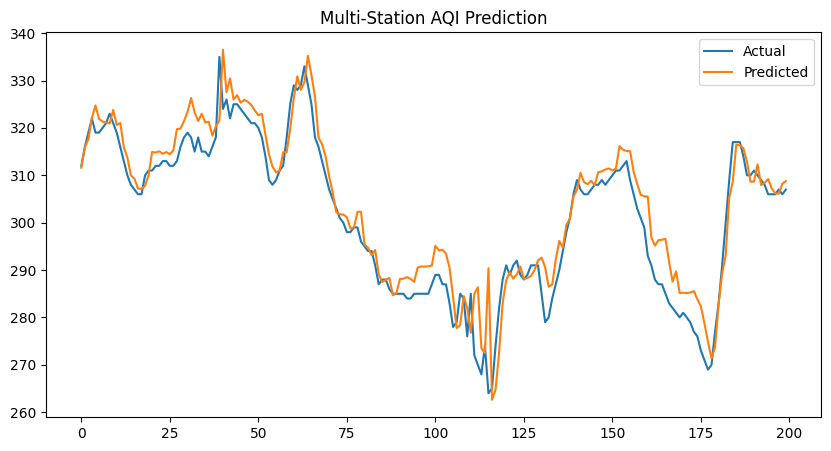

In [157]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(pred[:200], label="Predicted")
plt.legend()
plt.title("Multi-Station AQI Prediction")
plt.show()

In [158]:
print("Relevant stations:", relevant_stations)
print("Count:", len(relevant_stations))

Relevant stations: ['DTU', 'DWARKASEC8', 'Mundka', 'NARELA', 'Najfgarh']
Count: 5
